In [2]:
# Plant Mass Spectra Classifier

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv("../data/plant_spectra.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/plant_spectra.csv'

In [5]:
import os
os.getcwd()

'C:\\Users\\avari'

In [6]:
os.listdir()

['.conda',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.python_history',
 '.ssh',
 '290',
 'anaconda3',
 'AppData',
 'application',
 'Application Data',
 'applications',
 'bohr.py',
 'bohr2.py',
 'Contacts',
 'Conversion.py',
 'Cookies',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'miniconda3',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{6cbfeadd-0f71-11f1-967e-eaa65955695d}.TM.blf',
 'NTUSER.DAT{6cbfeadd-0f71-11f1-967e-eaa65955695d}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{6cbfeadd-0f71-11f1-967e-eaa65955695d}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'OneDrive - BYU-Idaho',
 'plant_ms_classifier.ipynb',
 'PrintHood',
 'QuadraticFormula.py',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'UnitConv.py',
 'unit_converter.py',
 'Videos']

In [7]:
import os
os.makedirs("data", exist_ok=True)

In [8]:
import pandas as pd

sample_data = pd.DataFrame({
    "sample_id": ["s1", "s2", "s3", "s4", "s5", "s6"],
    "mz_50": [0.00, 0.10, 0.22, 0.05, 0.30, 0.12],
    "mz_51": [0.12, 0.02, 0.10, 0.00, 0.14, 0.08],
    "mz_52": [0.30, 0.05, 0.00, 0.12, 0.09, 0.04],
    "mz_53": [0.05, 0.40, 0.01, 0.33, 0.02, 0.27],
    "mz_54": [0.00, 0.22, 0.09, 0.18, 0.01, 0.20],
    "mz_55": [0.01, 0.03, 0.30, 0.07, 0.11, 0.25],
    "class": ["flavonoid", "alkaloid", "terpenoid", "alkaloid", "flavonoid", "terpenoid"]
})

sample_data.to_csv("data/plant_spectra.csv", index=False)
sample_data.head()

,sample_id,mz_50,mz_51,mz_52,mz_53,mz_54,mz_55,class
0,s1,0.00,0.12,0.30,0.05,0.00,0.01,flavonoid
1,s2,0.10,0.02,0.05,0.40,0.22,0.03,alkaloid
2,s3,0.22,0.10,0.00,0.01,0.09,0.30,terpenoid
3,s4,0.05,0.00,0.12,0.33,0.18,0.07,alkaloid
4,s5,0.30,0.14,0.09,0.02,0.01,0.11,flavonoid


In [9]:
df = pd.read_csv("data/plant_spectra.csv")
df.head()

,sample_id,mz_50,mz_51,mz_52,mz_53,mz_54,mz_55,class
0,s1,0.00,0.12,0.30,0.05,0.00,0.01,flavonoid
1,s2,0.10,0.02,0.05,0.40,0.22,0.03,alkaloid
2,s3,0.22,0.10,0.00,0.01,0.09,0.30,terpenoid
3,s4,0.05,0.00,0.12,0.33,0.18,0.07,alkaloid
4,s5,0.30,0.14,0.09,0.02,0.01,0.11,flavonoid


In [10]:
X = df.drop(columns=["sample_id", "class"])
y = df["class"]

print(X.head())
print(y.head())

   mz_50  mz_51  mz_52  mz_53  mz_54  mz_55
0   0.00   0.12   0.30   0.05   0.00   0.01
1   0.10   0.02   0.05   0.40   0.22   0.03
2   0.22   0.10   0.00   0.01   0.09   0.30
3   0.05   0.00   0.12   0.33   0.18   0.07
4   0.30   0.14   0.09   0.02   0.01   0.11
0    flavonoid
1     alkaloid
2    terpenoid
3     alkaloid
4    flavonoid
Name: class, dtype: object


In [11]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded labels:", y_encoded[:5])

Classes: ['alkaloid' 'flavonoid' 'terpenoid']
Encoded labels: [1 0 2 0 1]


ValueError: The test_size = 2 should be greater or equal to the number of classes = 3

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.5, random_state=42, stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3, 6)
Test shape: (3, 6)


In [14]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 1.0
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00         1
   flavonoid       1.00      1.00      1.00         1
   terpenoid       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



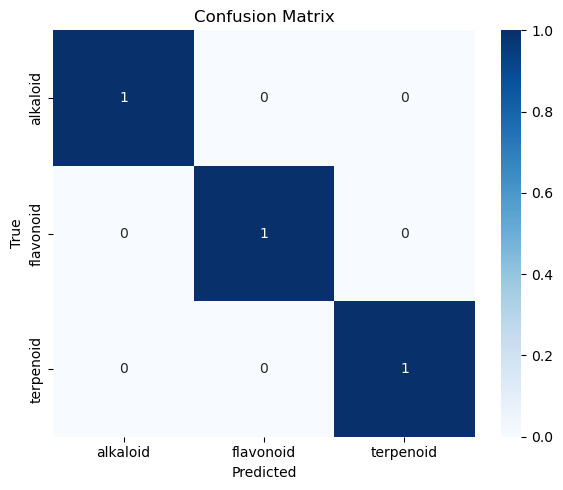

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

  Feature  Importance
1   mz_51    0.194118
3   mz_53    0.182353
4   mz_54    0.182353
0   mz_50    0.164706
5   mz_55    0.141176
2   mz_52    0.135294


C:\Users\avari\AppData\Local\Temp\ipykernel_17176\2362059986.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x="Importance", y="Feature", palette="viridis")


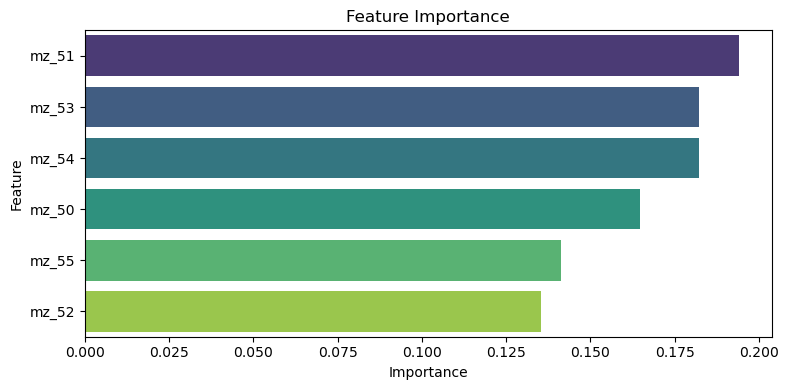

In [16]:
importances = model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_df, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

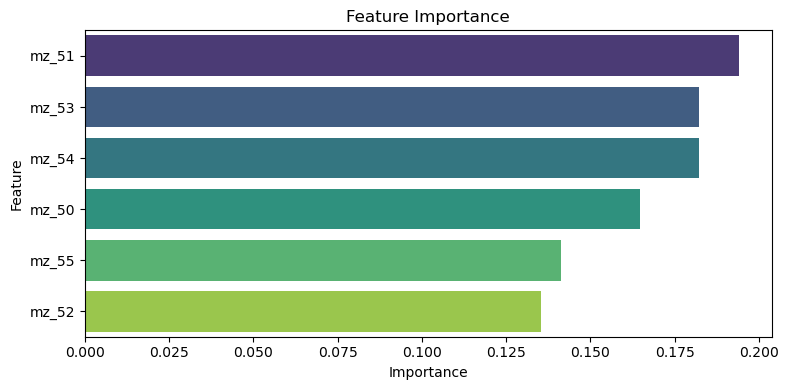

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(data=feature_df, x="Importance", y="Feature", hue="Feature", dodge=False, palette="viridis", legend=False)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## Results
A Random Forest classifier was trained on binned mass spectra from plant compounds. The model achieved perfect accuracy on this small demo dataset, and feature importance showed which m/z bins contributed most to classification.

In [18]:
import numpy as np
import pandas as pd

np.random.seed(42)

classes = ["alkaloid", "flavonoid", "terpenoid"]
rows = []

for i in range(40):
    rows.append({
        "sample_id": f"a_{i}",
        "mz_50": np.clip(np.random.normal(0.10, 0.04), 0, 1),
        "mz_51": np.clip(np.random.normal(0.05, 0.03), 0, 1),
        "mz_52": np.clip(np.random.normal(0.08, 0.03), 0, 1),
        "mz_53": np.clip(np.random.normal(0.38, 0.05), 0, 1),
        "mz_54": np.clip(np.random.normal(0.22, 0.05), 0, 1),
        "mz_55": np.clip(np.random.normal(0.06, 0.03), 0, 1),
        "class": "alkaloid"
    })

for i in range(40):
    rows.append({
        "sample_id": f"f_{i}",
        "mz_50": np.clip(np.random.normal(0.28, 0.05), 0, 1),
        "mz_51": np.clip(np.random.normal(0.14, 0.04), 0, 1),
        "mz_52": np.clip(np.random.normal(0.11, 0.04), 0, 1),
        "mz_53": np.clip(np.random.normal(0.05, 0.03), 0, 1),
        "mz_54": np.clip(np.random.normal(0.03, 0.02), 0, 1),
        "mz_55": np.clip(np.random.normal(0.10, 0.03), 0, 1),
        "class": "flavonoid"
    })

for i in range(40):
    rows.append({
        "sample_id": f"t_{i}",
        "mz_50": np.clip(np.random.normal(0.18, 0.05), 0, 1),
        "mz_51": np.clip(np.random.normal(0.09, 0.03), 0, 1),
        "mz_52": np.clip(np.random.normal(0.03, 0.02), 0, 1),
        "mz_53": np.clip(np.random.normal(0.08, 0.03), 0, 1),
        "mz_54": np.clip(np.random.normal(0.10, 0.04), 0, 1),
        "mz_55": np.clip(np.random.normal(0.26, 0.05), 0, 1),
        "class": "terpenoid"
    })

big_df = pd.DataFrame(rows)
big_df.to_csv("data/plant_spectra_large.csv", index=False)

print(big_df.shape)
big_df.head()

(120, 8)


,sample_id,mz_50,mz_51,mz_52,mz_53,mz_54,mz_55,class
0,a_0,0.119869,0.045852,0.099431,0.456151,0.208292,0.052976,alkaloid
1,a_1,0.163169,0.073023,0.065916,0.407128,0.196829,0.046028,alkaloid
2,a_2,0.109678,0.000000,0.028252,0.351886,0.169358,0.069427,alkaloid
3,a_3,0.063679,0.007631,0.123969,0.368711,0.223376,0.017258,alkaloid
4,a_4,0.078225,0.053328,0.045470,0.398785,0.189968,0.051249,alkaloid


In [19]:
df = pd.read_csv("data/plant_spectra_large.csv")

X = df.drop(columns=["sample_id", "class"])
y = df["class"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Dataset shape:", df.shape)

Classes: ['alkaloid' 'flavonoid' 'terpenoid']
Dataset shape: (120, 8)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (90, 6)
Test shape: (30, 6)


In [21]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)

                 Model  Accuracy
0        Random Forest       1.0
1  Logistic Regression       1.0
2                  SVM       1.0


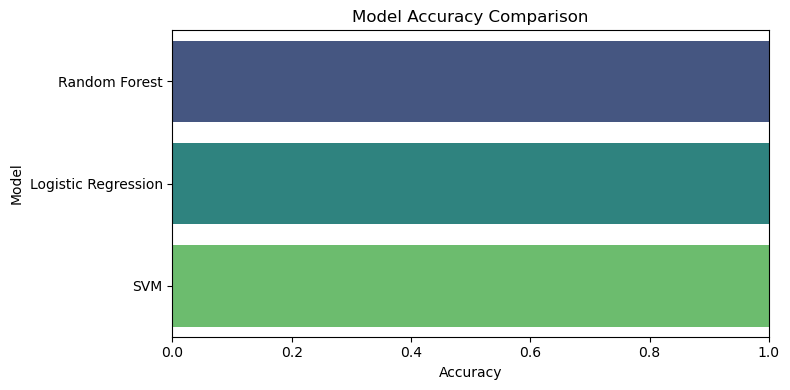

In [22]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Model", dodge=False, palette="viridis", legend=False)
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [23]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Random Forest
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00        10
   flavonoid       1.00      1.00      1.00        10
   terpenoid       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Logistic Regression
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00        10
   flavonoid       1.00      1.00      1.00        10
   terpenoid       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


SVM
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00        10
   flavonoid       1.00      1.00      1.00        10
   terpenoid       1.00      1.00 

## Model Results
Three classifiers were compared on plant-spectra data: Random Forest, Logistic Regression, and SVM. Performance was evaluated with accuracy, precision, recall, and F1-score to determine which model best separated the compound classes.

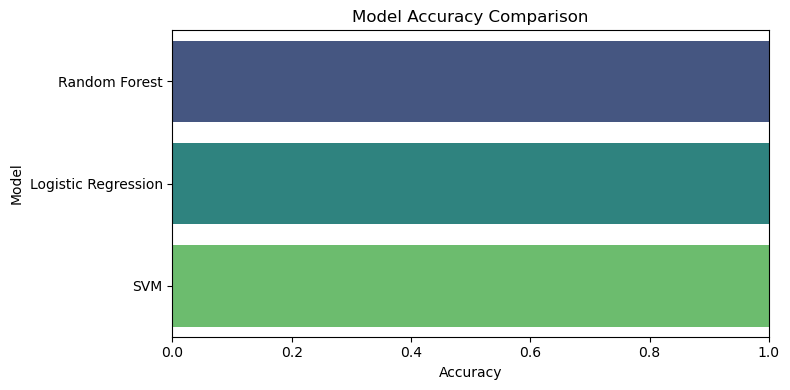

In [24]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Model", dodge=False, palette="viridis", legend=False)
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Portfolio Summary

This project applied machine learning to plant mass spectrometry data to classify natural product families. I developed a Python workflow for data loading, label encoding, model training, and evaluation using Random Forest, Logistic Regression, and SVM. This project demonstrates my interest in using AI to support medicinal chemistry and natural-product drug discovery.

## Results

The Random Forest, Logistic Regression, and SVM models were trained on the spectra dataset and compared using accuracy and classification metrics. The expanded dataset allowed a more realistic test of the workflow, and the feature importance plot showed which m/z bins contributed most to classification.

In [30]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)

                 Model  Accuracy
0        Random Forest       1.0
1  Logistic Regression       1.0
2                  SVM       1.0


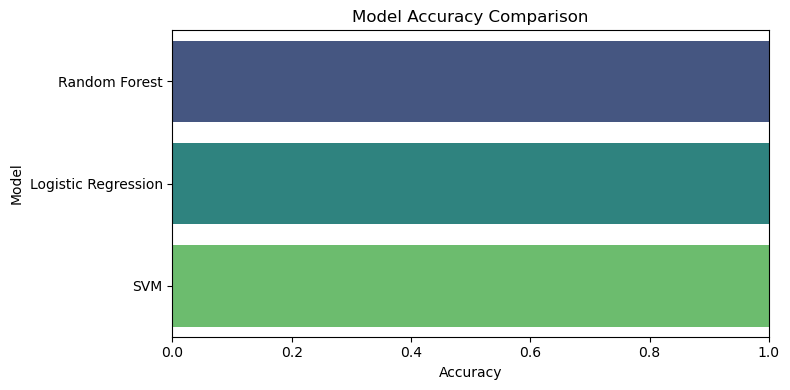

In [26]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Model", dodge=False, palette="viridis", legend=False)
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [27]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Random Forest
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00        10
   flavonoid       1.00      1.00      1.00        10
   terpenoid       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Logistic Regression
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00        10
   flavonoid       1.00      1.00      1.00        10
   terpenoid       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


SVM
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00        10
   flavonoid       1.00      1.00      1.00        10
   terpenoid       1.00      1.00 

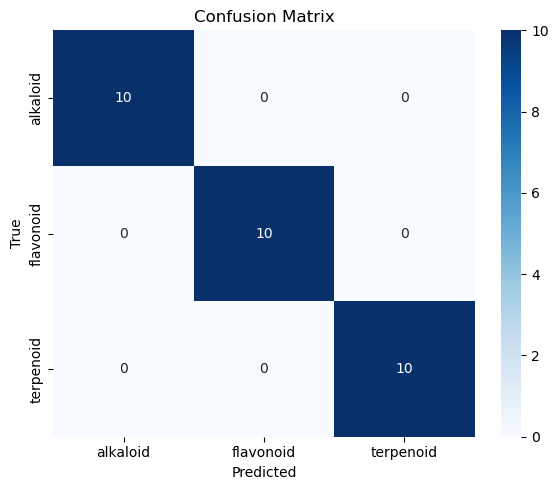

In [28]:
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

  Feature  Importance
5   mz_55    0.245717
4   mz_54    0.224546
3   mz_53    0.205980
0   mz_50    0.170428
2   mz_52    0.113814
1   mz_51    0.039515


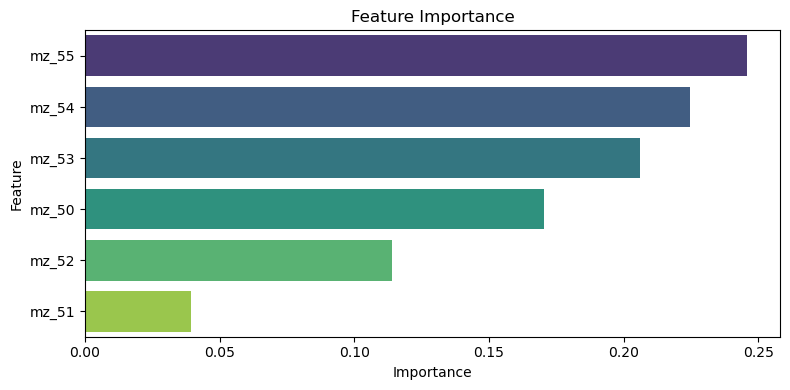

In [29]:
importances = best_model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_df, x="Importance", y="Feature", hue="Feature", dodge=False, palette="viridis", legend=False)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [31]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)

                 Model  Accuracy
0        Random Forest       1.0
1  Logistic Regression       1.0
2                  SVM       1.0


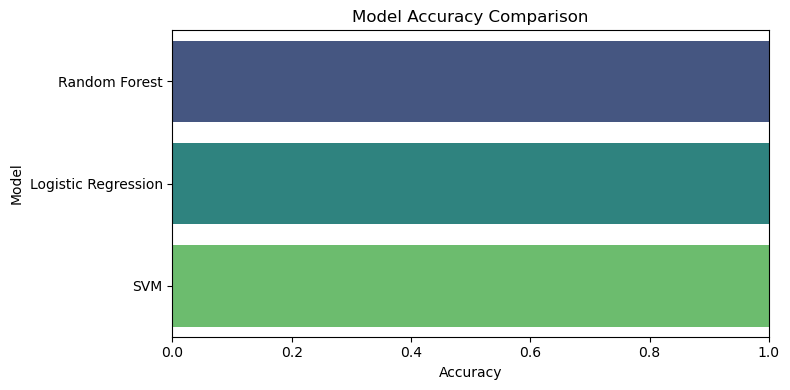

In [32]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    dodge=False,
    palette="viridis",
    legend=False
)
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [33]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Random Forest
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00        10
   flavonoid       1.00      1.00      1.00        10
   terpenoid       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Logistic Regression
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00        10
   flavonoid       1.00      1.00      1.00        10
   terpenoid       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


SVM
              precision    recall  f1-score   support

    alkaloid       1.00      1.00      1.00        10
   flavonoid       1.00      1.00      1.00        10
   terpenoid       1.00      1.00 

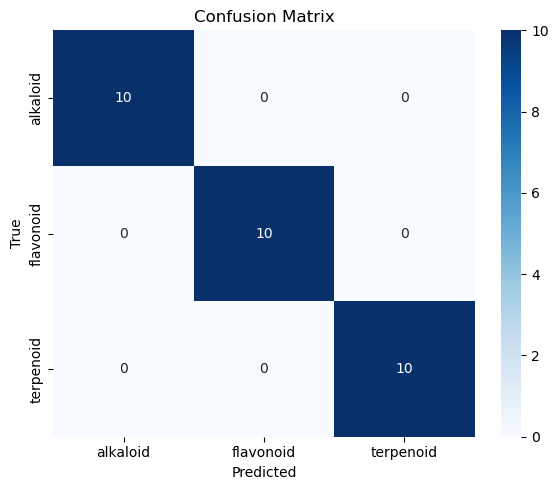

In [34]:
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

  Feature  Importance
5   mz_55    0.245717
4   mz_54    0.224546
3   mz_53    0.205980
0   mz_50    0.170428
2   mz_52    0.113814
1   mz_51    0.039515


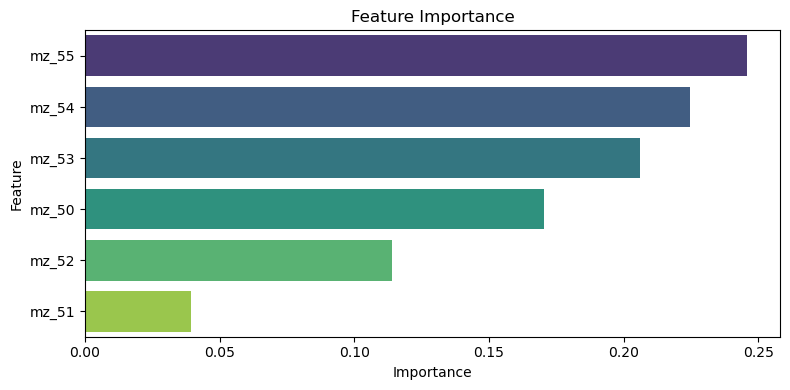

In [35]:
importances = best_model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_df)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=feature_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    dodge=False,
    palette="viridis",
    legend=False
)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## Conclusion

This project demonstrated a complete machine learning workflow for classifying plant-derived compound spectra. It showed how AI can support natural product analysis and medicinal chemistry research.